# 05 — Calibration-sweep diagnostics over the \(\nu_u\) grid

This notebook implements the four-section structure in \`Reference_notes/On_Calibration_variablet_set.md\` for

\[
\nu_u\in\{1.25,1.00,0.75\},\qquad \xi_u=2.25,\qquad \nu_b=\xi_W=0.
\]

Each requested case is first tested at the no-buffer horizon \(T=80\). If that attempt is not residual-safe, the notebook uses warm horizon continuation to locate the largest residual-safe no-buffer prefix, and plots the case only through

\[
T_{\mathrm{plot}}=\min\{80,T_{\mathrm{safe}}\}.
\]

The switch plots use a realized switch date \(\tau=16\), marked by a vertical line. All HKT and bubble-share objects below are finite-prefix diagnostics; they are not, by themselves, infinite-tail theorem certificates.


In [1]:
using Pkg

const NB05_DIRNAME = "Two_country_proudction_zero_nu_b"
const NB05_MODEL_CANDIDATES = unique(normpath.([
    joinpath(pwd(), NB05_DIRNAME, "TwoCountryProductionOLG.jl"),
    joinpath(pwd(), "Codes", NB05_DIRNAME, "TwoCountryProductionOLG.jl"),
    joinpath(dirname(pwd()), NB05_DIRNAME, "TwoCountryProductionOLG.jl"),
]))
nb05_model_idx = findfirst(isfile, NB05_MODEL_CANDIDATES)
isnothing(nb05_model_idx) && error("Cannot find the zero-nu-b solver. Checked:\n" *
    join(NB05_MODEL_CANDIDATES, "\n"))
const NB05_MODEL_FILE = NB05_MODEL_CANDIDATES[nb05_model_idx]
const NB05_CODES_ROOT = dirname(dirname(NB05_MODEL_FILE))
Pkg.activate(NB05_CODES_ROOT)
include(NB05_MODEL_FILE)

using Plots, LaTeXStrings, Printf, Markdown
gr()

const NB05_OUTDIR = joinpath(dirname(NB05_MODEL_FILE), "outputs_zero_nu_b",
    "05_nu_u_funding_regime_sweeps")
mkpath(NB05_OUTDIR)

const NB05_TARGET_T = 80
const NB05_DIRECT_ITERS = 80
const NB05_BRANCH_ITERS = 500
const NB05_RESID_TOL = 1e-5
const NB05_SWITCH_TAU = 16
const NB05_CASES = [
    (id="nu_u_1_25", label="νᵤ = 1.25", ν_u=1.25),
    (id="nu_u_1_00", label="νᵤ = 1.00", ν_u=1.00),
    (id="nu_u_0_75", label="νᵤ = 0.75", ν_u=0.75),
]
const NB05_COLORS = Dict(
    "nu_u_1_25"=>:navy, "nu_u_1_00"=>:seagreen3, "nu_u_0_75"=>:red3,
)
const NB05_PATH_STYLES = Dict(:all_u=>:solid, :realized_switch=>:dash)

function nb05_params(case, T; branch_iters=NB05_BRANCH_ITERS)
    ProductionParams(
        T_max=T, n_buffer=0, branch_iters=branch_iters,
        common_world_growth=false, do_global_polish=false,
        β=0.45, γ=0.25, π_persist=0.75,
        a_US=0.20, ϑ_US=0.85,
        a_W=0.06, H_W=3.0, L_W=3.0,
        A_X_US_u=15.0, A_L_US_u=1.5,
        ν_b=0.0, ν_u=case.ν_u, ξ_u=2.25, ξ_W=0.0,
        ω̄=0.50, ω̄_star=0.25,
        κ=1.00, χ=0.0002, η=0.010,
    )
end

for case in NB05_CASES
    p = nb05_params(case, 2)
    @assert p.ξ_u > p.ν_u > p.ν_b == 0.0
    @assert p.ξ_u == 2.25 && p.ξ_W == 0.0 && p.n_buffer == 0
end

function nb05_csv_cell(x)
    if x === missing
        return ""
    elseif x isa AbstractString
        return "\"" * replace(x, "\"" => "\"\"") * "\""
    elseif x isa Bool
        return lowercase(string(x))
    end
    return string(x)
end

function nb05_write_csv(path, rows, columns)
    open(path, "w") do io
        println(io, join(columns, ','))
        for row in rows
            println(io, join((nb05_csv_cell(getproperty(row, Symbol(c))) for c in columns), ','))
        end
    end
    path
end

@info "Initialized Notebook 05" NB05_MODEL_FILE NB05_OUTDIR NB05_TARGET_T NB05_SWITCH_TAU


  Activating 

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`
┌ Info: Initialized Notebook 05
│   NB05_MODEL_FILE = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/TwoCountryProductionOLG.jl"
│   NB05_OUTDIR = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/05_nu_u_funding_regime_sweeps"
│   NB05_TARGET_T = 80
└   NB05_SWITCH_TAU = 16


## 0. Residual-safe, no-buffer horizons

A solve is called residual-safe only if the branch reports convergence and both the maximum \(u\)-branch and absorbing-branch residuals are at most \(10^{-5}\). The direct \(T=80\) pass uses parameter continuation across the requested \(\nu_u\) grid. Any failed direct case is then re-solved from \(T=30\) with warm horizon continuation. Every numerical attempt—including a failed one—is retained in the solve log.


In [2]:
nb05_residual_safe(r) =
    r !== nothing && r.branch_converged &&
    isfinite(r.max_u_residual) && r.max_u_residual <= NB05_RESID_TOL &&
    isfinite(r.max_bgp_residual) && r.max_bgp_residual <= NB05_RESID_TOL

function nb05_attempt(case, T; seed=nothing, branch_iters=NB05_BRANCH_ITERS, mode="")
    started = time()
    try
        p = nb05_params(case, T; branch_iters)
        result = seed === nothing ?
            run_production_simulation(p; verbose=false) :
            run_production_simulation(p; verbose=false,
                initial_u_path=seed.u_path_extended,
                initial_bgp_seq=seed.bgp_seq_extended)
        safe = nb05_residual_safe(result)
        return (case_id=case.id, label=case.label, nu_u=case.ν_u, T=T,
            mode=mode, branch_iters=branch_iters,
            warm_start=seed === nothing ? "none" : "yes",
            elapsed_sec=time()-started, safe=safe,
            branch_converged=result.branch_converged,
            max_u_residual=result.max_u_residual,
            max_bgp_residual=result.max_bgp_residual,
            error="", result=result)
    catch err
        return (case_id=case.id, label=case.label, nu_u=case.ν_u, T=T,
            mode=mode, branch_iters=branch_iters,
            warm_start=seed === nothing ? "none" : "yes",
            elapsed_sec=time()-started, safe=false,
            branch_converged=false, max_u_residual=Inf,
            max_bgp_residual=Inf, error=sprint(showerror, err), result=nothing)
    end
end

function nb05_push_attempt!(rows, a)
    push!(rows, (case_id=a.case_id, nu_u=a.nu_u, T=a.T, mode=a.mode,
        branch_iters=a.branch_iters, warm_start=a.warm_start,
        elapsed_sec=a.elapsed_sec, residual_safe=a.safe,
        branch_converged=a.branch_converged,
        max_u_residual=a.max_u_residual,
        max_bgp_residual=a.max_bgp_residual, error=a.error))
end

function nb05_parameter_seed_T30(target_case, rows)
    seed = nothing
    for case in NB05_CASES
        a = nb05_attempt(case, 30; seed=seed, branch_iters=NB05_BRANCH_ITERS,
            mode="fallback_parameter_continuation_T30")
        nb05_push_attempt!(rows, a)
        a.safe || return nothing
        seed = a.result
        case.id == target_case.id && return seed
    end
    nothing
end

function nb05_fallback_search(case, rows)
    seed = nb05_parameter_seed_T30(case, rows)
    seed === nothing && return (result=nothing, horizon=0, note="unavailable: T=30 unsafe")
    last_safe = 30
    coarse_targets = (45, 60, 70, 75, 78, 79, 80)

    for target in coarse_targets
        a = nb05_attempt(case, target; seed=seed, branch_iters=NB05_BRANCH_ITERS,
            mode="fallback_horizon_continuation")
        nb05_push_attempt!(rows, a)
        if a.safe
            seed = a.result
            last_safe = target
            target == NB05_TARGET_T &&
                return (result=seed, horizon=last_safe,
                    note="T=80 reached by residual-safe horizon continuation")
        else
            for T in (last_safe + 1):(target - 1)
                b = nb05_attempt(case, T; seed=seed, branch_iters=NB05_BRANCH_ITERS,
                    mode="fallback_exact_frontier_search")
                nb05_push_attempt!(rows, b)
                b.safe || return (result=seed, horizon=last_safe,
                    note="largest residual-safe no-buffer horizon found below T=$target")
                seed = b.result
                last_safe = T
            end
            return (result=seed, horizon=last_safe,
                note="largest residual-safe no-buffer horizon; T=$target was unsafe")
        end
    end
    (result=seed, horizon=last_safe, note="largest residual-safe no-buffer horizon")
end
nothing


In [3]:
nb05_attempt_rows = NamedTuple[]
nb05_solutions = Dict{String,Any}()
nb05_horizons = Dict{String,Int}()
nb05_horizon_notes = Dict{String,String}()
nb05_direct = Dict{String,Any}()

direct_seed = nothing
for case in NB05_CASES
    @printf("Direct T=80 check: %-11s ... ", case.id)
    a = nb05_attempt(case, NB05_TARGET_T; seed=direct_seed,
        branch_iters=NB05_DIRECT_ITERS, mode="direct_T80_check")
    nb05_push_attempt!(nb05_attempt_rows, a)
    nb05_direct[case.id] = a
    @printf("safe=%s, max u residual=%.3e, elapsed=%.2fs\n",
        a.safe, a.max_u_residual, a.elapsed_sec)
    if a.safe
        nb05_solutions[case.id] = a.result
        nb05_horizons[case.id] = NB05_TARGET_T
        nb05_horizon_notes[case.id] = "direct residual-safe T=80 check"
        direct_seed = a.result
    end
end

for case in NB05_CASES
    haskey(nb05_solutions, case.id) && continue
    @printf("Fallback horizon search: %-11s ...\n", case.id)
    fallback = nb05_fallback_search(case, nb05_attempt_rows)
    if fallback.result !== nothing
        nb05_solutions[case.id] = fallback.result
        nb05_horizons[case.id] = min(NB05_TARGET_T, fallback.horizon)
    else
        nb05_horizons[case.id] = 0
    end
    nb05_horizon_notes[case.id] = fallback.note
end

nb05_horizon_rows = [(case_id=case.id, nu_u=case.ν_u,
    direct_T80_safe=nb05_direct[case.id].safe,
    direct_T80_max_u_residual=nb05_direct[case.id].max_u_residual,
    residual_safe_no_buffer_horizon=nb05_horizons[case.id],
    min_80_safe_horizon=min(NB05_TARGET_T, nb05_horizons[case.id]),
    available=haskey(nb05_solutions, case.id),
    note=nb05_horizon_notes[case.id]) for case in NB05_CASES]

nb05_write_csv(joinpath(NB05_OUTDIR, "residual_safe_horizon_summary.csv"),
    nb05_horizon_rows, String.(propertynames(first(nb05_horizon_rows))))
nb05_write_csv(joinpath(NB05_OUTDIR, "residual_safe_horizon_attempts.csv"),
    nb05_attempt_rows, String.(propertynames(first(nb05_attempt_rows))))

horizon_table = [
    "| calibration | direct T=80 safe? | max direct u residual | min{80, safe no-buffer T} | status |",
    "|---|---:|---:|---:|---|",
]
for r in nb05_horizon_rows
    push!(horizon_table, @sprintf("| νᵤ=%.2f | %s | %.3e | %d | %s |",
        r.nu_u, r.direct_T80_safe, r.direct_T80_max_u_residual,
        r.min_80_safe_horizon, r.note))
end
display(Markdown.parse(join(horizon_table, "\n")))


Direct T=80 check: nu_u_1_25   ... safe=true, max u residual=1.884e-07, elapsed=0.99s


Direct T=80 check: nu_u_1_00   ... safe=true, max u residual=1.212e-06, elapsed=0.06s


Direct T=80 check: nu_u_0_75   ... safe=false, max u residual=4.401e-01, elapsed=97.48s


Fallback horizon search: nu_u_0_75   ...


| calibration | direct T=80 safe? | max direct u residual | min{80, safe no-buffer T} |                                             status |
| -----------:| -----------------:| ---------------------:| -------------------------:| --------------------------------------------------:|
|     νᵤ=1.25 |              true |             1.884e-07 |                        80 |                    direct residual-safe T=80 check |
|     νᵤ=1.00 |              true |             1.212e-06 |                        80 |                    direct residual-safe T=80 check |
|     νᵤ=0.75 |             false |             4.401e-01 |                        80 | T=80 reached by residual-safe horizon continuation |


## 1. R&D Allocation, Growth, and the U.S. Stock-Funding Identity

### 1.1 Growth-related quantities

For each calibration, the next two figures report the 20 requested country-path-quantity combinations:

\[
2\text{ paths}\times 2\text{ countries}\times 5\text{ quantities}=20.
\]

The all-\(u\) path is the continued unbalanced branch. The realized switch path remains on \(u\) for \(t<\tau\) and follows the absorbing \(b\) regime for \(t\ge \tau\), with \(\tau=16\). This is a realized post-switch evolution, not merely a one-period \(b\)-successor evaluated at each all-\(u\) state.


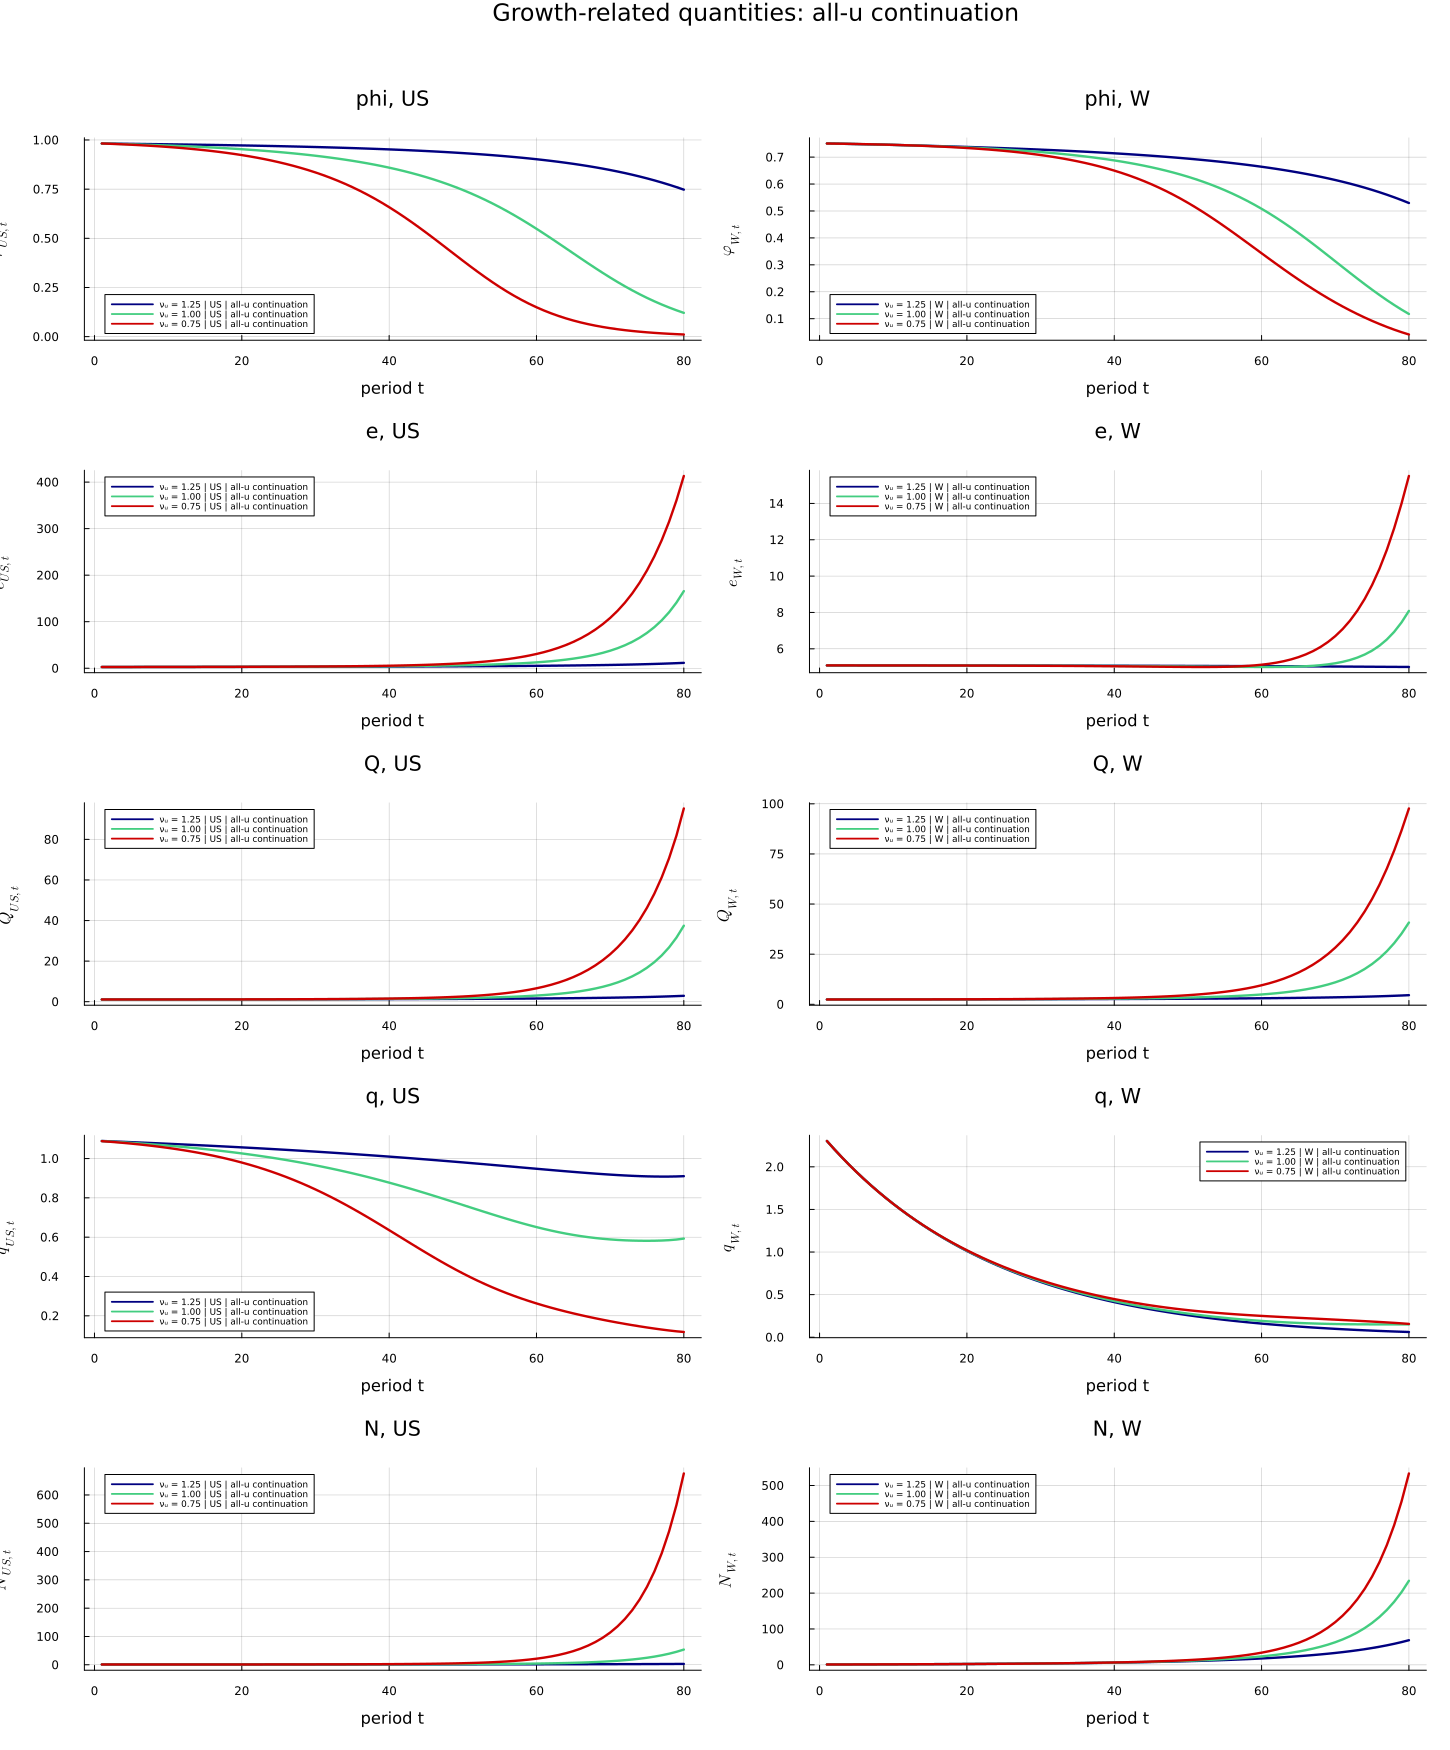

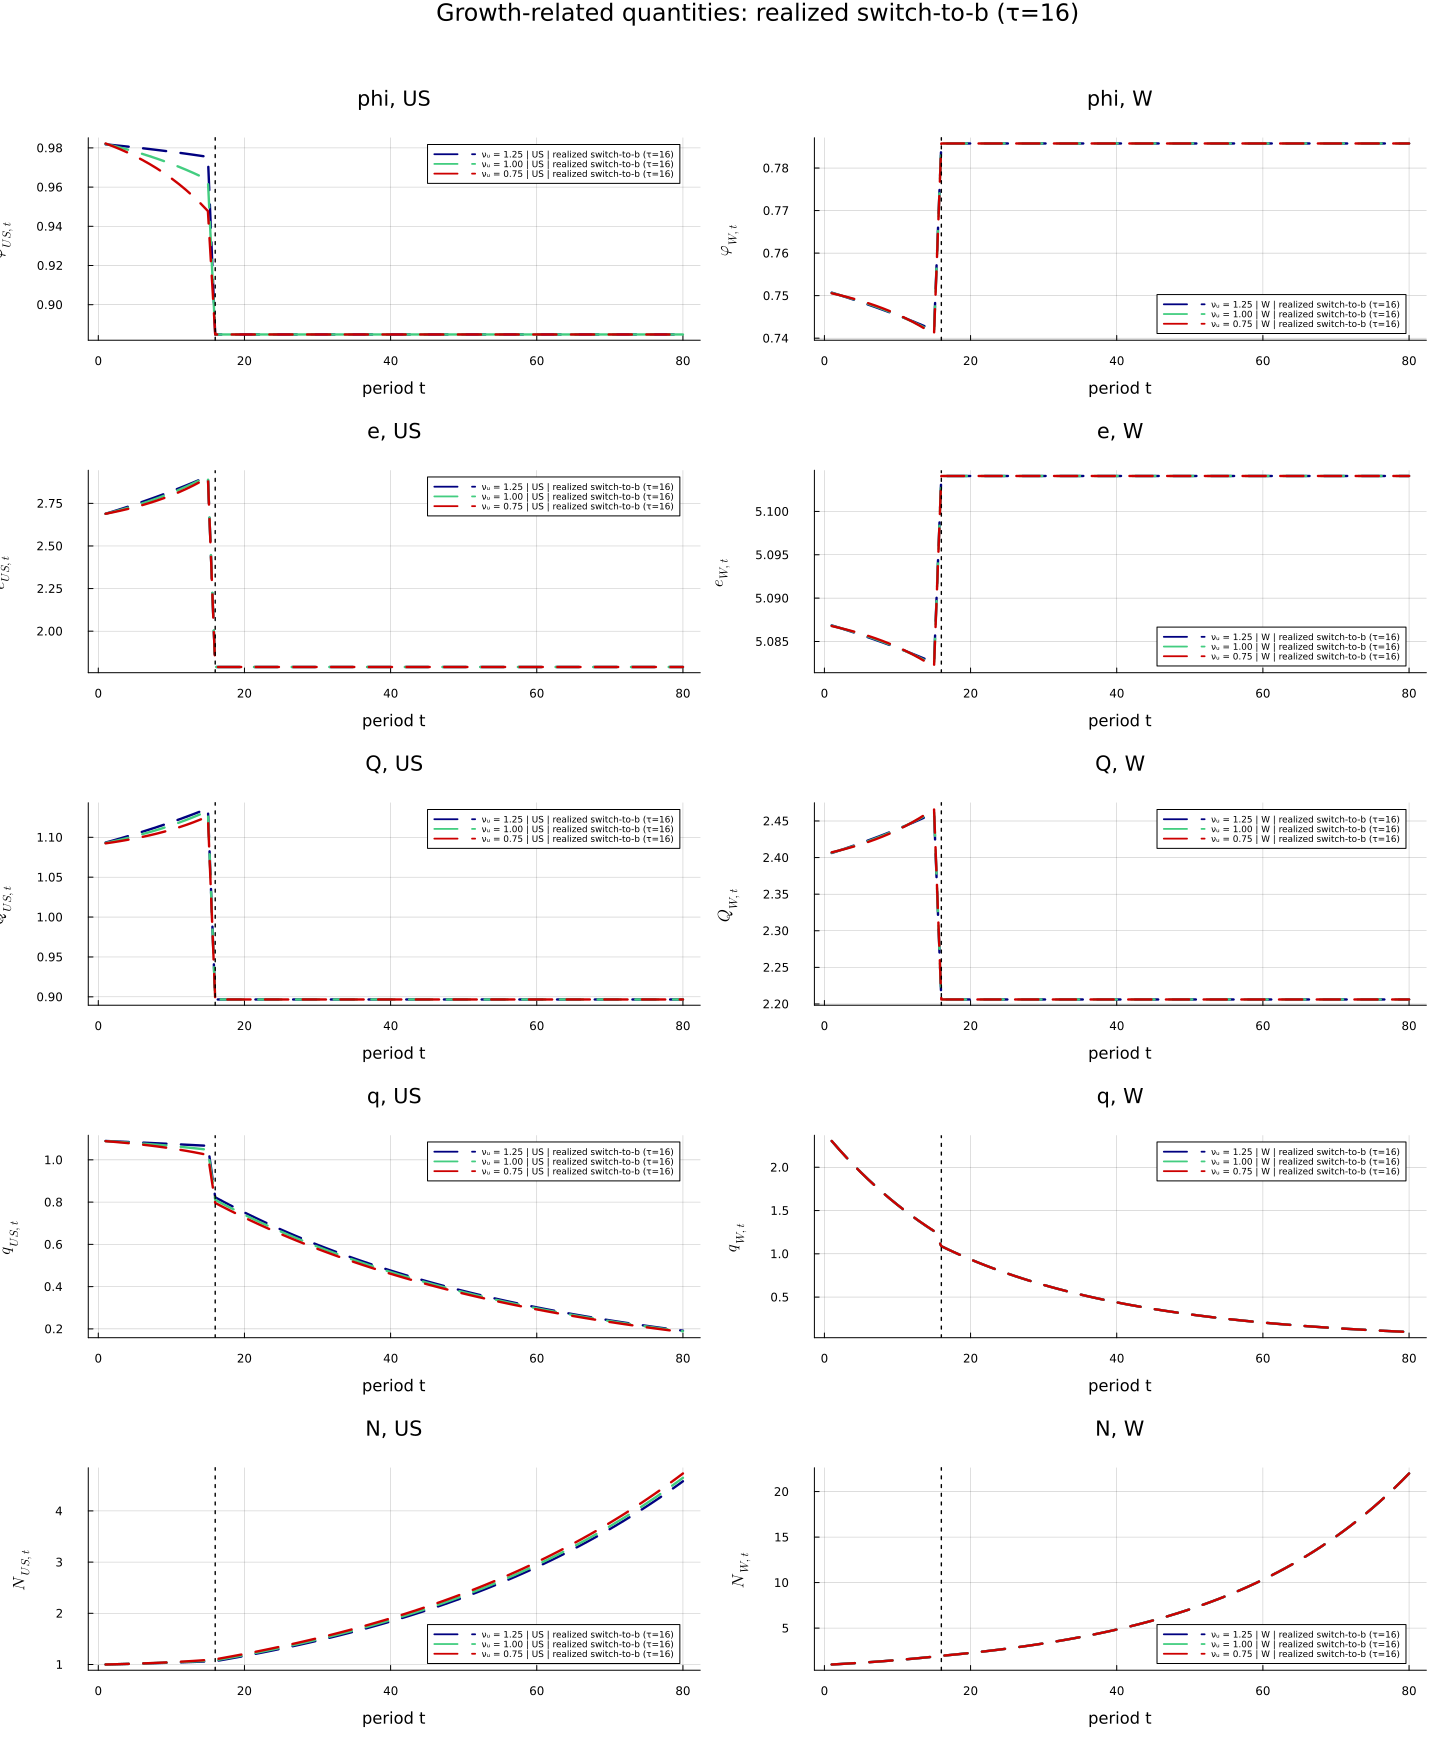

In [4]:
const NB05_STATE_SPECS = [
    (name="phi", us=:φ_US, w=:φ_W, us_label=L"\varphi_{US,t}", w_label=L"\varphi_{W,t}"),
    (name="e", us=:e_US, w=:e_W, us_label=L"e_{US,t}", w_label=L"e_{W,t}"),
    (name="Q", us=:Q_US, w=:Q_W, us_label=L"Q_{US,t}", w_label=L"Q_{W,t}"),
    (name="q", us=:q_US, w=:q_W, us_label=L"q_{US,t}", w_label=L"q_{W,t}"),
    (name="N", us=:N_US, w=:N_W, us_label=L"N_{US,t}", w_label=L"N_{W,t}"),
]

nb05_path_data = NamedTuple[]
for case in NB05_CASES
    haskey(nb05_solutions, case.id) || continue
    result = nb05_solutions[case.id]
    Tplot = nb05_horizons[case.id]
    all_u = result.u_path[1:Tplot]
    realized = Tplot >= NB05_SWITCH_TAU ?
        build_switch_path(result, NB05_SWITCH_TAU; T=Tplot) : NamedTuple[]
    push!(nb05_path_data, (case=case, T=Tplot, all_u=all_u, realized=realized))
end

state_rows = NamedTuple[]
for d in nb05_path_data
    for (path_name, path) in (("all_u", d.all_u), ("realized_switch", d.realized))
        isempty(path) && continue
        for (j, s) in enumerate(path)
            regime = path_name == "all_u" ? "u" : string(s.regime)
            push!(state_rows, (case_id=d.case.id, nu_u=d.case.ν_u,
                path=path_name, switch_tau=NB05_SWITCH_TAU, t=j, regime=regime,
                phi_US=getproperty(s,:φ_US), phi_W=getproperty(s,:φ_W),
                e_US=getproperty(s,:e_US), e_W=getproperty(s,:e_W),
                Q_US=getproperty(s,:Q_US), Q_W=getproperty(s,:Q_W),
                q_US=getproperty(s,:q_US), q_W=getproperty(s,:q_W),
                N_US=getproperty(s,:N_US), N_W=getproperty(s,:N_W)))
        end
    end
end
nb05_write_csv(joinpath(NB05_OUTDIR, "all_u_and_realized_switch_state_paths.csv"),
    state_rows, String.(propertynames(first(state_rows))))

function nb05_state_figure(path_kind::Symbol)
    panels = Any[]
    is_switch = path_kind == :realized_switch
    path_title = is_switch ? "realized switch-to-b (τ=$(NB05_SWITCH_TAU))" : "all-u continuation"
    for spec in NB05_STATE_SPECS, country in (:US, :W)
        field = country == :US ? spec.us : spec.w
        ylabel = country == :US ? spec.us_label : spec.w_label
        p = plot(; title="$(spec.name), $(country)", xlabel="period t", ylabel=ylabel,
            legend=:best, legendfontsize=6, gridalpha=0.25)
        for d in nb05_path_data
            path = is_switch ? d.realized : d.all_u
            isempty(path) && continue
            values = Float64[getproperty(s, field) for s in path]
            label = "$(d.case.label) | $(country) | $(path_title)"
            plot!(p, 1:length(path), values; lw=2.4,
                ls=NB05_PATH_STYLES[path_kind],
                color=NB05_COLORS[d.case.id], label=label)
        end
        is_switch && vline!(p, [NB05_SWITCH_TAU]; color=:black, ls=:dot, lw=1.4,
            label=false)
        push!(panels, p)
    end
    plot(panels...; layout=(5,2), size=(1450,1750), margin=4Plots.mm,
        plot_title="Growth-related quantities: $path_title")
end

fig_all_u = nb05_state_figure(:all_u)
savefig(fig_all_u, joinpath(NB05_OUTDIR, "all_u_state_paths_nu_u_sweep.png"))
display(fig_all_u)

fig_realized_switch = nb05_state_figure(:realized_switch)
savefig(fig_realized_switch, joinpath(NB05_OUTDIR, "realized_switch_to_b_state_paths_nu_u_sweep.png"))
fig_realized_switch


### 1.2 U.S. stock-funding components

Along the all-\(u\) path, define

\[
A_t=\frac{s_We_{W,t}^u}{\beta e_{US,t}^u},\qquad
B_t=\frac{Q_{W,t}^u}{\beta e_{US,t}^u},\qquad
\zeta_t=1+A_t-B_t,
\]

and, equivalently,

\[
m_t=\frac{e_{W,t}^u}{e_{US,t}^u},\qquad
\mu_t=\frac{Q_{W,t}^u}{e_{W,t}^u},\qquad
\zeta_t=1+\frac{m_t}{\beta}(s_W-\mu_t),
\quad s_W=\frac{\beta+\chi}{1+\chi}.
\]


In [5]:
function nb05_case_diagnostics(case, result, Tplot)
    p = result.params
    u = result.u_path[1:Tplot]
    t = collect(1:Tplot)
    s_W = (p.β + p.χ) / (1 + p.χ)
    A = Float64[s_W*s.e_W/(p.β*s.e_US) for s in u]
    B = Float64[s.Q_W/(p.β*s.e_US) for s in u]
    gap = A .- B
    zeta = Float64[s.Q_US/(p.β*s.e_US) for s in u]
    m = Float64[s.e_W/s.e_US for s in u]
    mu = Float64[s.Q_W/s.e_W for s in u]
    scale = m ./ p.β
    wedge = s_W .- mu
    contribution = scale .* wedge
    zeta_AB = 1 .+ gap
    zeta_ratio = 1 .+ contribution
    return (case=case, result=result, p=p, u=u, t=t, s_W=s_W,
        A=A, B=B, gap=gap, zeta=zeta, m=m, mu=mu, scale=scale,
        wedge=wedge, contribution=contribution,
        zeta_AB=zeta_AB, zeta_ratio=zeta_ratio,
        identity_error_AB=maximum(abs.(zeta .- zeta_AB)),
        identity_error_ratio=maximum(abs.(zeta .- zeta_ratio)))
end

nb05_diag = [nb05_case_diagnostics(case, nb05_solutions[case.id],
    nb05_horizons[case.id]) for case in NB05_CASES if haskey(nb05_solutions, case.id)]

funding_rows = NamedTuple[]
for d in nb05_diag, j in eachindex(d.t)
    push!(funding_rows, (case_id=d.case.id, nu_u=d.case.ν_u, t=d.t[j],
        s_W=d.s_W, A_t=d.A[j], B_t=d.B[j], A_minus_B=d.gap[j],
        zeta_direct=d.zeta[j], zeta_from_A_B=d.zeta_AB[j],
        m_t=d.m[j], mu_t=d.mu[j], m_over_beta=d.scale[j],
        s_W_minus_mu=d.wedge[j], zeta_minus_one=d.contribution[j],
        zeta_from_ratio=d.zeta_ratio[j]))
end
nb05_write_csv(joinpath(NB05_OUTDIR, "stock_funding_and_ratio_paths.csv"),
    funding_rows, String.(propertynames(first(funding_rows))))

funding_summary = [(case_id=d.case.id, nu_u=d.case.ν_u, T_plot=length(d.t),
    zeta_initial=first(d.zeta), zeta_final=last(d.zeta),
    max_AB_identity_error=d.identity_error_AB,
    max_ratio_identity_error=d.identity_error_ratio) for d in nb05_diag]
nb05_write_csv(joinpath(NB05_OUTDIR, "stock_funding_identity_summary.csv"),
    funding_summary, String.(propertynames(first(funding_summary))))

for d in nb05_diag
    @assert d.identity_error_AB <= NB05_RESID_TOL
    @assert d.identity_error_ratio <= NB05_RESID_TOL
end

identity_table = [
    "| calibration | T plot | ζ first | ζ last | max A/B identity error | max ratio identity error |",
    "|---|---:|---:|---:|---:|---:|",
]
for r in funding_summary
    push!(identity_table, @sprintf("| νᵤ=%.2f | %d | %.5f | %.5f | %.3e | %.3e |",
        r.nu_u, r.T_plot, r.zeta_initial, r.zeta_final,
        r.max_AB_identity_error, r.max_ratio_identity_error))
end
display(Markdown.parse(join(identity_table, "\n")))


| calibration | T plot | ζ first |  ζ last | max A/B identity error | max ratio identity error |
| -----------:| ------:| -------:| -------:| ----------------------:| ------------------------:|
|     νᵤ=1.25 |     80 | 0.90361 | 0.55705 |              1.736e-08 |                1.736e-08 |
|     νᵤ=1.00 |     80 | 0.90321 | 0.50213 |              1.831e-08 |                1.831e-08 |
|     νᵤ=0.75 |     80 | 0.90279 | 0.51222 |              2.933e-09 |                2.933e-09 |


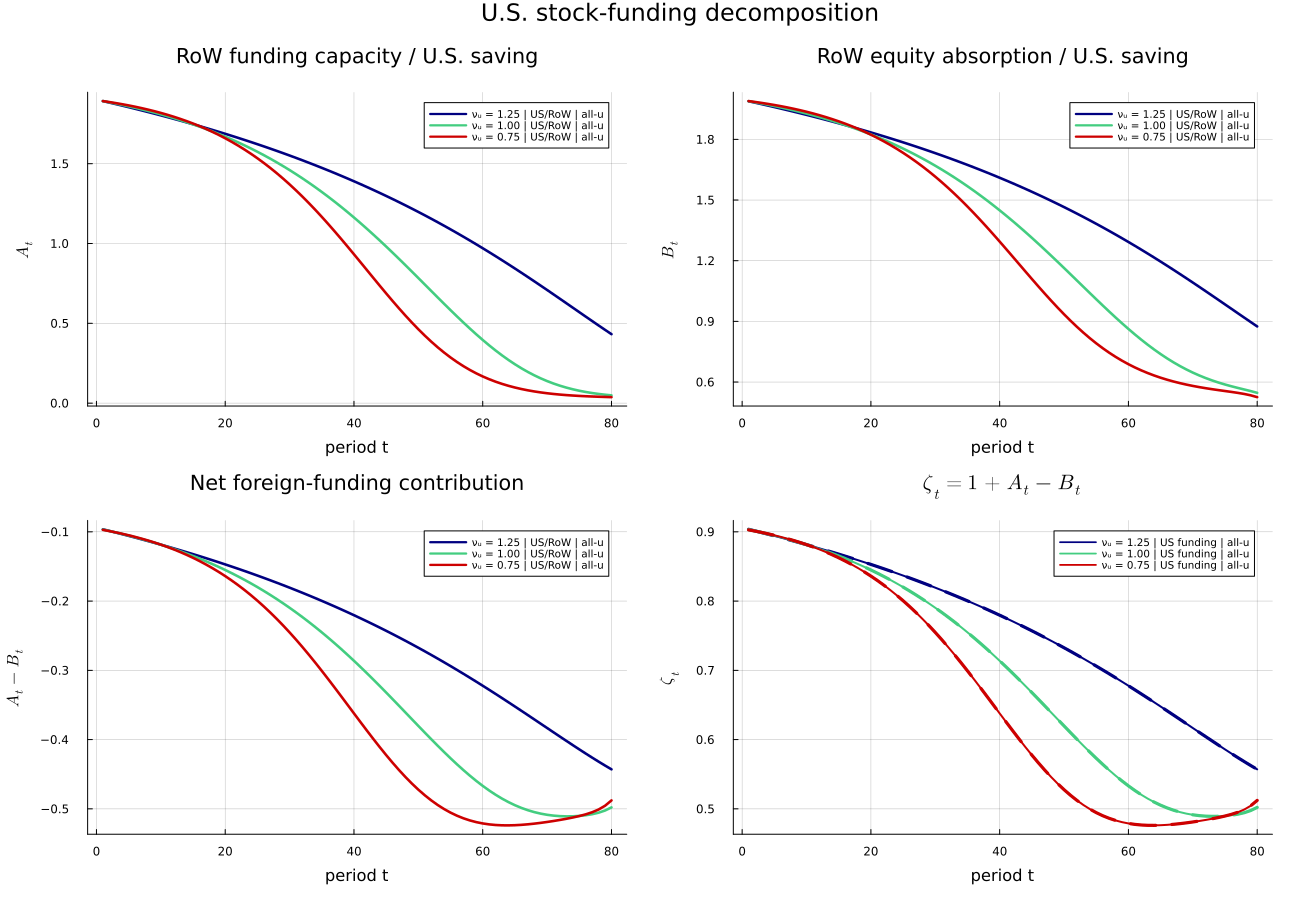

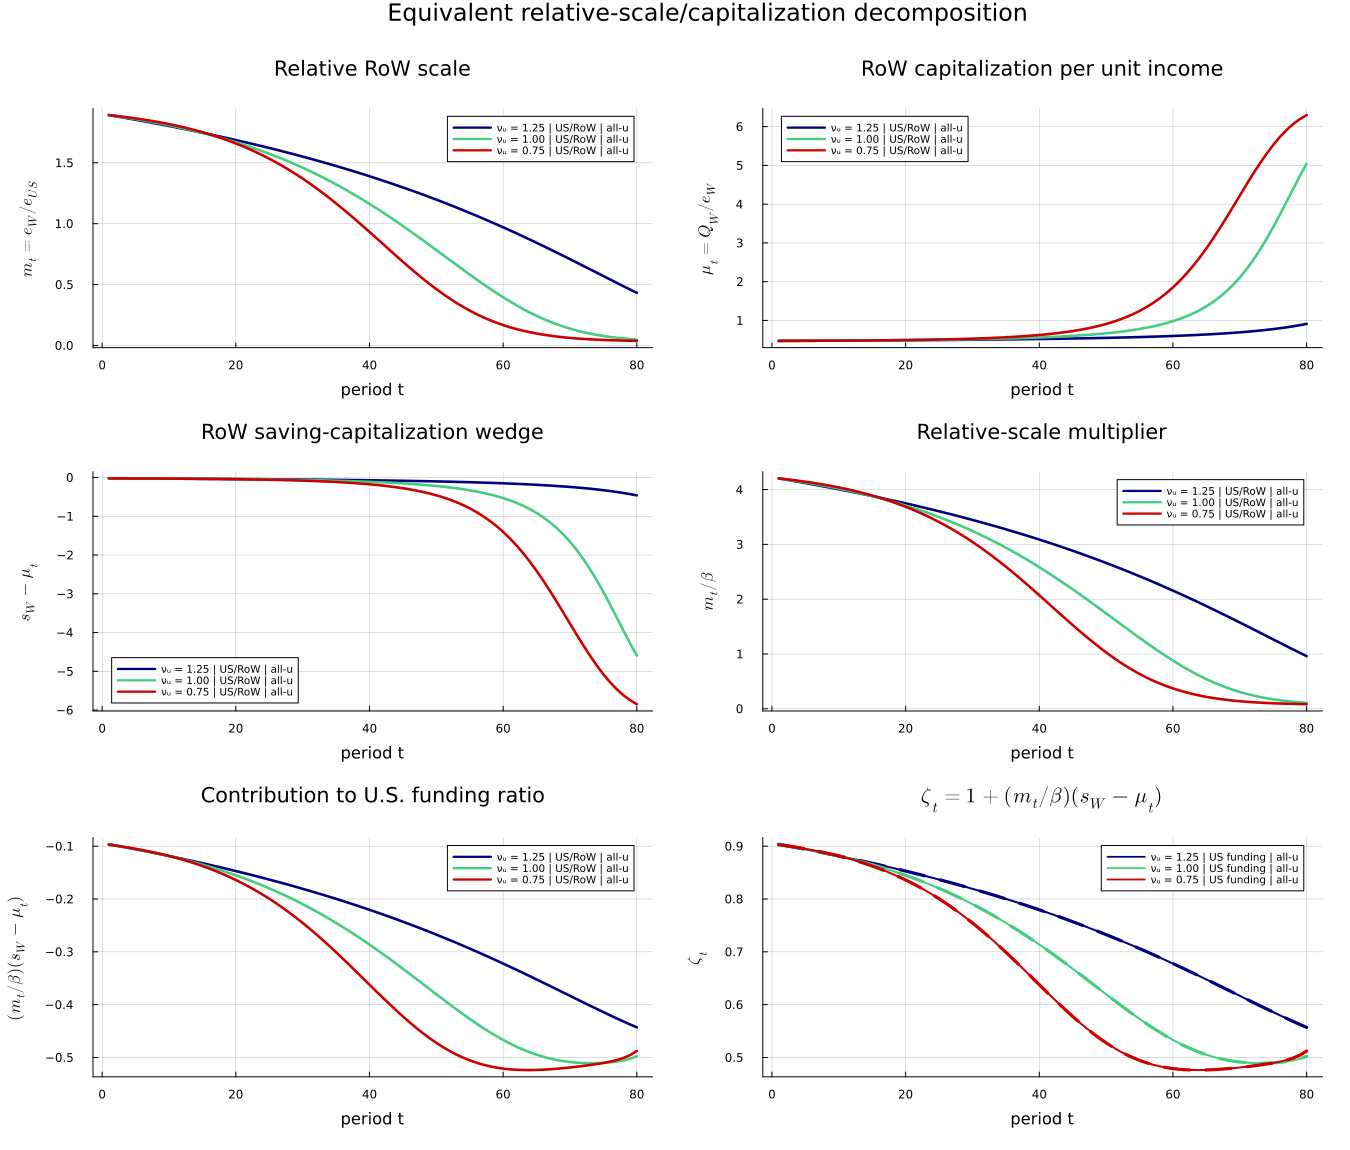

In [6]:
function nb05_panel(getter; title, ylabel, dataset=nb05_diag,
    label_suffix="US/RoW | all-u")
    p = plot(; title=title, xlabel="period t", ylabel=ylabel,
        legend=:best, legendfontsize=7, gridalpha=0.25)
    for d in dataset
        plot!(p, d.t, getter(d); lw=2.6, color=NB05_COLORS[d.case.id],
            label="$(d.case.label) | $label_suffix")
    end
    p
end

p_A = nb05_panel(d->d.A; title="RoW funding capacity / U.S. saving", ylabel=L"A_t")
p_B = nb05_panel(d->d.B; title="RoW equity absorption / U.S. saving", ylabel=L"B_t")
p_gap = nb05_panel(d->d.gap; title="Net foreign-funding contribution", ylabel=L"A_t-B_t")
p_zeta_AB = plot(; title=L"\zeta_t=1+A_t-B_t", xlabel="period t",
    ylabel=L"\zeta_t", legend=:best, legendfontsize=7, gridalpha=0.25)
for d in nb05_diag
    plot!(p_zeta_AB, d.t, d.zeta_AB; lw=3.2, ls=:dash,
        color=NB05_COLORS[d.case.id], label=false)
    plot!(p_zeta_AB, d.t, d.zeta; lw=2.0, color=NB05_COLORS[d.case.id],
        label="$(d.case.label) | US funding | all-u")
end
fig_funding = plot(p_A, p_B, p_gap, p_zeta_AB; layout=(2,2), size=(1300,900),
    margin=5Plots.mm, plot_title="U.S. stock-funding decomposition")
savefig(fig_funding, joinpath(NB05_OUTDIR, "funding_identity_nu_u_sweep.png"))
display(fig_funding)

p_m = nb05_panel(d->d.m; title="Relative RoW scale", ylabel=L"m_t=e_W/e_{US}")
p_mu = nb05_panel(d->d.mu; title="RoW capitalization per unit income", ylabel=L"\mu_t=Q_W/e_W")
p_wedge = nb05_panel(d->d.wedge; title="RoW saving-capitalization wedge", ylabel=L"s_W-\mu_t")
p_scale = nb05_panel(d->d.scale; title="Relative-scale multiplier", ylabel=L"m_t/\beta")
p_product = nb05_panel(d->d.contribution; title="Contribution to U.S. funding ratio",
    ylabel=L"(m_t/\beta)(s_W-\mu_t)")
p_zeta_ratio = plot(; title=L"\zeta_t=1+(m_t/\beta)(s_W-\mu_t)",
    xlabel="period t", ylabel=L"\zeta_t", legend=:best, legendfontsize=7, gridalpha=0.25)
for d in nb05_diag
    plot!(p_zeta_ratio, d.t, d.zeta_ratio; lw=3.2, ls=:dash,
        color=NB05_COLORS[d.case.id], label=false)
    plot!(p_zeta_ratio, d.t, d.zeta; lw=2.0, color=NB05_COLORS[d.case.id],
        label="$(d.case.label) | US funding | all-u")
end
fig_relative = plot(p_m, p_mu, p_wedge, p_scale, p_product, p_zeta_ratio;
    layout=(3,2), size=(1350,1150), margin=5Plots.mm,
    plot_title="Equivalent relative-scale/capitalization decomposition")
savefig(fig_relative, joinpath(NB05_OUTDIR,
    "relative_scale_capitalization_nu_u_sweep.png"))
fig_relative


## 2. Finite-Prefix Diagnostics for the HKT Tail Reduction

The following plots ask whether the residual-safe all-\(u\) prefix enters and remains in a U.S.-dominant region. They are finite-prefix diagnostics only. They do **not** establish that the corresponding inequalities continue to hold over the infinite tail.

For \(z\in\{u,b\}\),

\[
\Lambda_t^z=\frac{R_{A,t}^z}{R_{US,t}^z}.
\]


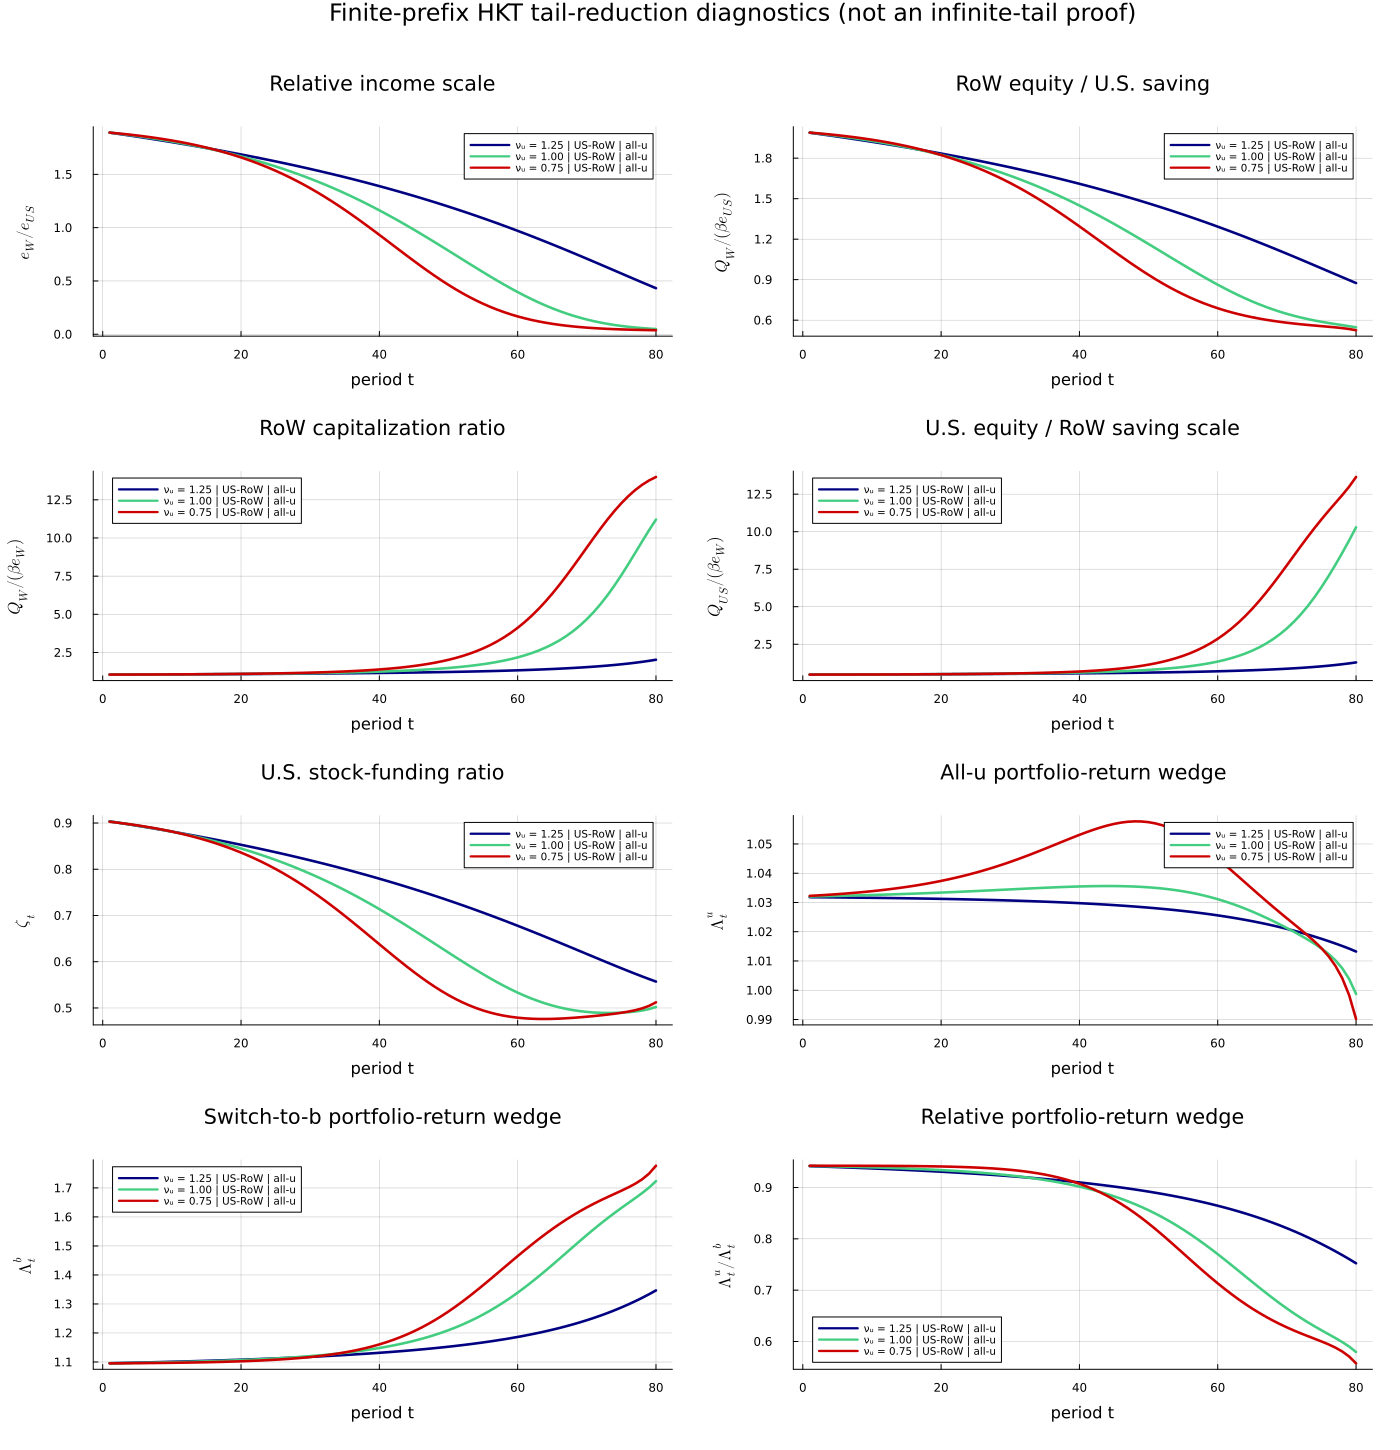

In [7]:
nb05_hkt = NamedTuple[]
hkt_rows = NamedTuple[]
for d in nb05_diag
    p = d.p
    e_ratio = d.m
    QW_beta_eUS = d.B
    QW_beta_eW = Float64[s.Q_W/(p.β*s.e_W) for s in d.u]
    QUS_beta_eW = Float64[s.Q_US/(p.β*s.e_W) for s in d.u]
    lambda_u = Float64[s.R_A_u/s.R_US_u for s in d.u]
    lambda_b = Float64[s.R_A_b/s.R_US_b for s in d.u]
    lambda_ratio = lambda_u ./ lambda_b
    x = (d=d, e_ratio=e_ratio, QW_beta_eUS=QW_beta_eUS,
        QW_beta_eW=QW_beta_eW, QUS_beta_eW=QUS_beta_eW,
        zeta=d.zeta, lambda_u=lambda_u, lambda_b=lambda_b,
        lambda_ratio=lambda_ratio)
    push!(nb05_hkt, x)
    for j in eachindex(d.t)
        push!(hkt_rows, (case_id=d.case.id, nu_u=d.case.ν_u, t=d.t[j],
            e_W_over_e_US=e_ratio[j], Q_W_over_beta_e_US=QW_beta_eUS[j],
            Q_W_over_beta_e_W=QW_beta_eW[j], Q_US_over_beta_e_W=QUS_beta_eW[j],
            zeta=d.zeta[j], Lambda_u=lambda_u[j], Lambda_b=lambda_b[j],
            Lambda_u_over_Lambda_b=lambda_ratio[j]))
    end
end
nb05_write_csv(joinpath(NB05_OUTDIR, "finite_prefix_hkt_diagnostics.csv"),
    hkt_rows, String.(propertynames(first(hkt_rows))))

hkt_specs = [
    (get=x->x.e_ratio, title="Relative income scale", ylabel=L"e_W/e_{US}"),
    (get=x->x.QW_beta_eUS, title="RoW equity / U.S. saving", ylabel=L"Q_W/(\beta e_{US})"),
    (get=x->x.QW_beta_eW, title="RoW capitalization ratio", ylabel=L"Q_W/(\beta e_W)"),
    (get=x->x.QUS_beta_eW, title="U.S. equity / RoW saving scale", ylabel=L"Q_{US}/(\beta e_W)"),
    (get=x->x.zeta, title="U.S. stock-funding ratio", ylabel=L"\zeta_t"),
    (get=x->x.lambda_u, title="All-u portfolio-return wedge", ylabel=L"\Lambda_t^u"),
    (get=x->x.lambda_b, title="Switch-to-b portfolio-return wedge", ylabel=L"\Lambda_t^b"),
    (get=x->x.lambda_ratio, title="Relative portfolio-return wedge", ylabel=L"\Lambda_t^u/\Lambda_t^b"),
]
hkt_panels = Any[]
for spec in hkt_specs
    p = plot(; title=spec.title, xlabel="period t", ylabel=spec.ylabel,
        legend=:best, legendfontsize=7, gridalpha=0.25)
    for x in nb05_hkt
        plot!(p, x.d.t, spec.get(x); lw=2.6, color=NB05_COLORS[x.d.case.id],
            label="$(x.d.case.label) | US-RoW | all-u")
    end
    push!(hkt_panels, p)
end
fig_hkt = plot(hkt_panels...; layout=(4,2), size=(1400,1450), margin=5Plots.mm,
    plot_title="Finite-prefix HKT tail-reduction diagnostics (not an infinite-tail proof)")
savefig(fig_hkt, joinpath(NB05_OUTDIR, "finite_prefix_hkt_diagnostics_nu_u_sweep.png"))
fig_hkt


## 3. U.S. NFA Moments and VA/CA Decomposition

The accounting follows

\[
\Delta NFA_t=VA_t+CA_t.
\]

Valuation effects use beginning-of-period equity quantities and price changes; current-account effects use end-of-period prices and quantity changes, plus the change in the U.S. net bond position. The model holdings are

\[
n_{W,t}=\frac{(1-\omega_t)(1-\theta_t)A_t}{q_{W,t}},\qquad
n^*_{US,t}=\frac{\omega^*_t(1-\theta^*_{US,t})A^*_t}{q_{US,t}},\qquad
b_t=\theta_t A_t.
\]


In [8]:
function nb05_ahp_accounting(d)
    u = d.u
    T = length(u)
    q_US = Float64[s.q_US for s in u]
    q_W = Float64[s.q_W for s in u]
    n_W = Float64[(1-s.ω)*(1-s.θ)*s.A/s.q_W for s in u]
    n_US_star = Float64[s.ω_star*(1-s.θ_US_star)*s.A_star/s.q_US for s in u]
    bond = Float64[s.θ*s.A for s in u]
    asset_position = q_W .* n_W
    liability_position = q_US .* n_US_star
    NFA = asset_position .+ bond .- liability_position

    VA_asset=zeros(T); VA_liability=zeros(T)
    CA_asset=zeros(T); CA_liability=zeros(T); CA_bond=zeros(T)
    delta_NFA=zeros(T)
    for t in 2:T
        VA_asset[t] = n_W[t-1]*(q_W[t]-q_W[t-1])
        VA_liability[t] = -n_US_star[t-1]*(q_US[t]-q_US[t-1])
        CA_asset[t] = q_W[t]*(n_W[t]-n_W[t-1])
        CA_liability[t] = -q_US[t]*(n_US_star[t]-n_US_star[t-1])
        CA_bond[t] = bond[t]-bond[t-1]
        delta_NFA[t] = NFA[t]-NFA[t-1]
    end
    VA = VA_asset .+ VA_liability
    CA = CA_asset .+ CA_liability .+ CA_bond
    residual = delta_NFA .- VA .- CA
    equilibrium_NFA = Float64[s.A-s.Q_US for s in u]
    return (d=d, q_US=q_US, q_W=q_W, n_W=n_W, n_US_star=n_US_star,
        bond=bond, asset_position=asset_position, liability_position=liability_position,
        NFA=NFA, delta_NFA=delta_NFA, VA_asset=VA_asset,
        VA_liability=VA_liability, VA=VA, CA_asset=CA_asset,
        CA_liability=CA_liability, CA_bond=CA_bond, CA=CA,
        residual=residual,
        residual_max=maximum(abs.(residual[2:end])),
        equilibrium_nfa_error=maximum(abs.(NFA.-equilibrium_NFA)))
end

nb05_nfa = nb05_ahp_accounting.(nb05_diag)
nfa_rows = NamedTuple[]
for a in nb05_nfa, t in 1:length(a.d.t)
    push!(nfa_rows, (case_id=a.d.case.id, nu_u=a.d.case.ν_u, t=t,
        NFA=a.NFA[t], delta_NFA=a.delta_NFA[t],
        VA=a.VA[t], VA_asset=a.VA_asset[t], VA_liability=a.VA_liability[t],
        CA=a.CA[t], CA_asset=a.CA_asset[t], CA_liability=a.CA_liability[t],
        CA_bond=a.CA_bond[t], adding_up_residual=a.residual[t],
        n_W=a.n_W[t], n_US_star=a.n_US_star[t],
        q_W=a.q_W[t], q_US=a.q_US[t], bond=a.bond[t]))
end
nb05_write_csv(joinpath(NB05_OUTDIR, "us_nfa_va_ca_decomposition.csv"),
    nfa_rows, String.(propertynames(first(nfa_rows))))

nfa_summary = [(case_id=a.d.case.id, nu_u=a.d.case.ν_u,
    T_plot=length(a.d.t), max_adding_up_residual=a.residual_max,
    max_equilibrium_nfa_identity_error=a.equilibrium_nfa_error) for a in nb05_nfa]
nb05_write_csv(joinpath(NB05_OUTDIR, "us_nfa_identity_summary.csv"),
    nfa_summary, String.(propertynames(first(nfa_summary))))

for a in nb05_nfa
    @assert a.residual_max <= 1e-8
    @assert a.equilibrium_nfa_error <= NB05_RESID_TOL
end

nfa_table = [
    "| calibration | T plot | max ΔNFA-VA-CA residual | max equilibrium NFA identity error |",
    "|---|---:|---:|---:|",
]
for r in nfa_summary
    push!(nfa_table, @sprintf("| νᵤ=%.2f | %d | %.3e | %.3e |",
        r.nu_u, r.T_plot, r.max_adding_up_residual,
        r.max_equilibrium_nfa_identity_error))
end
display(Markdown.parse(join(nfa_table, "\n")))


| calibration | T plot | max ΔNFA-VA-CA residual | max equilibrium NFA identity error |
| -----------:| ------:| -----------------------:| ----------------------------------:|
|     νᵤ=1.25 |     80 |               4.996e-16 |                          3.317e-08 |
|     νᵤ=1.00 |     80 |               4.441e-15 |                          7.453e-07 |
|     νᵤ=0.75 |     80 |               1.066e-14 |                          3.707e-07 |


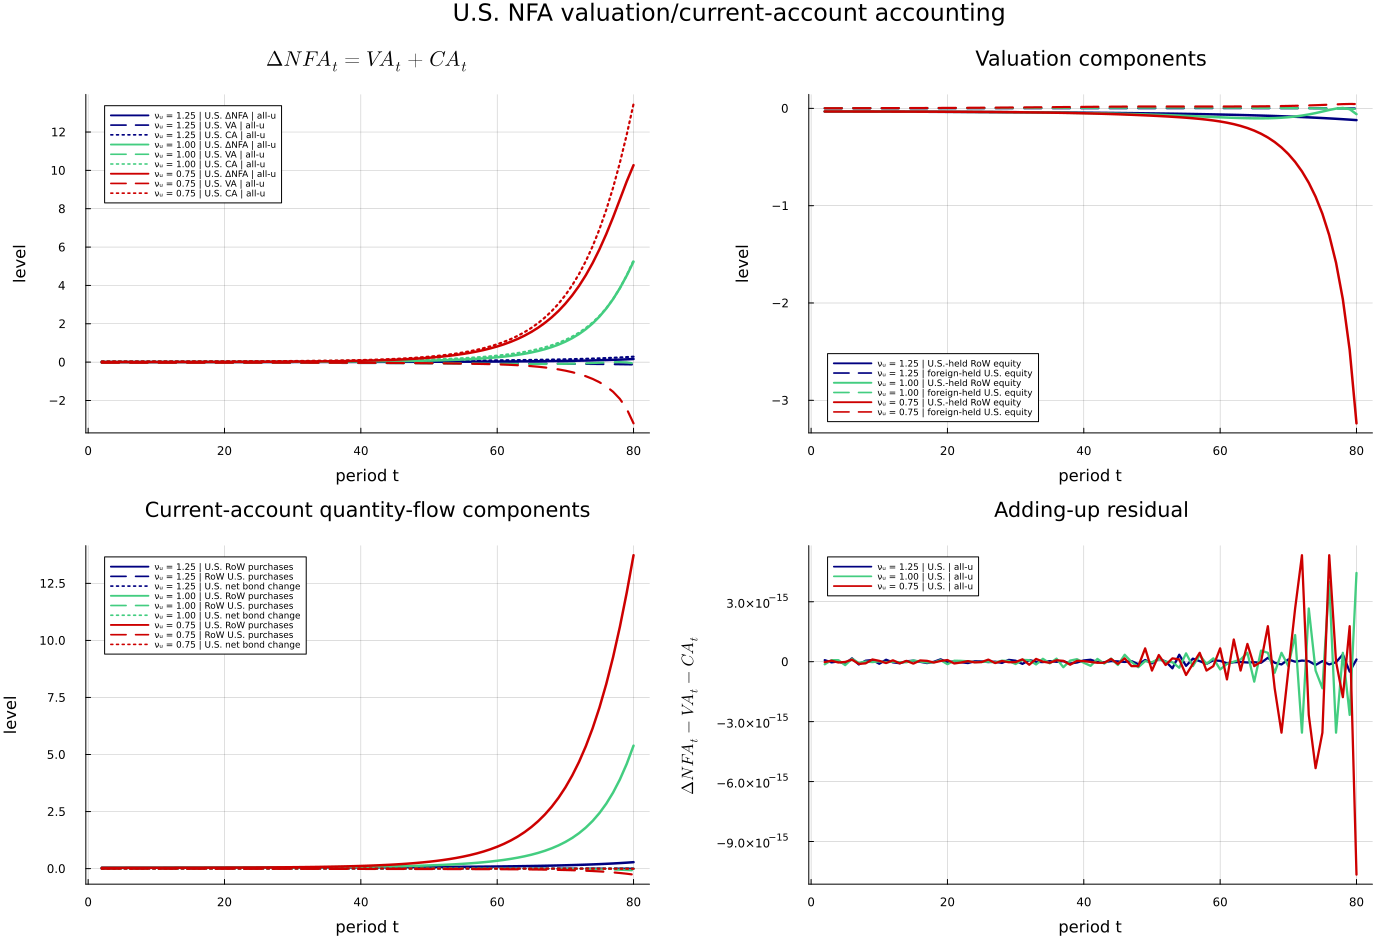

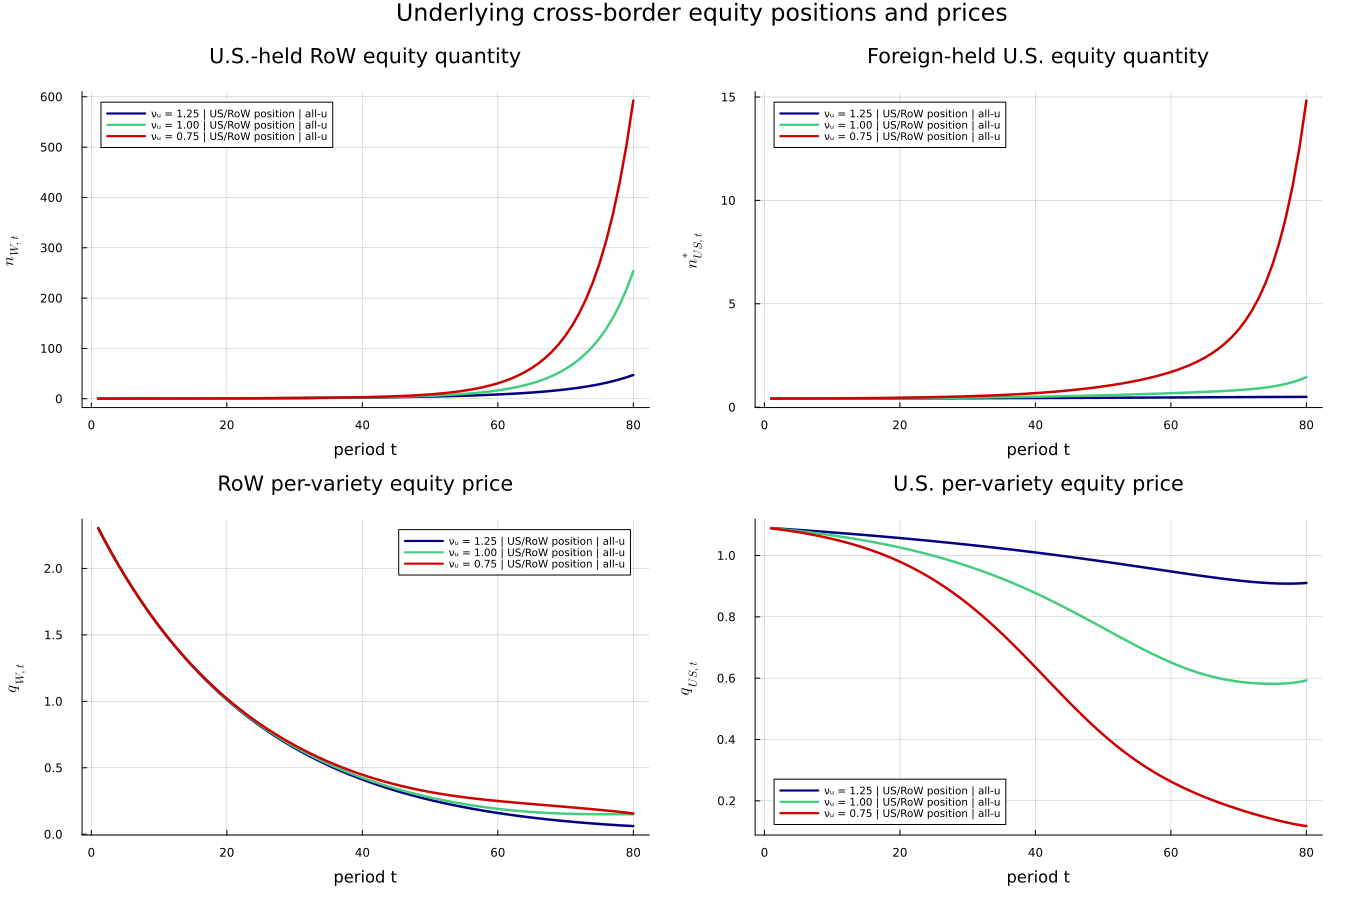

In [9]:
p_nfa = plot(; title=L"\Delta NFA_t=VA_t+CA_t", xlabel="period t", ylabel="level",
    legend=:best, legendfontsize=6, gridalpha=0.25)
p_va = plot(; title="Valuation components", xlabel="period t", ylabel="level",
    legend=:best, legendfontsize=6, gridalpha=0.25)
p_ca = plot(; title="Current-account quantity-flow components", xlabel="period t", ylabel="level",
    legend=:best, legendfontsize=6, gridalpha=0.25)
p_res = plot(; title="Adding-up residual", xlabel="period t",
    ylabel=L"\Delta NFA_t-VA_t-CA_t", legend=:best, legendfontsize=6, gridalpha=0.25)
for a in nb05_nfa
    t=2:length(a.d.t); c=NB05_COLORS[a.d.case.id]; lab=a.d.case.label
    plot!(p_nfa,t,a.delta_NFA[t];color=c,lw=2.5,ls=:solid,label="$lab | U.S. ΔNFA | all-u")
    plot!(p_nfa,t,a.VA[t];color=c,lw=2.2,ls=:dash,label="$lab | U.S. VA | all-u")
    plot!(p_nfa,t,a.CA[t];color=c,lw=2.2,ls=:dot,label="$lab | U.S. CA | all-u")
    plot!(p_va,t,a.VA_asset[t];color=c,lw=2.5,ls=:solid,label="$lab | U.S.-held RoW equity")
    plot!(p_va,t,a.VA_liability[t];color=c,lw=2.2,ls=:dash,label="$lab | foreign-held U.S. equity")
    plot!(p_ca,t,a.CA_asset[t];color=c,lw=2.5,ls=:solid,label="$lab | U.S. RoW purchases")
    plot!(p_ca,t,a.CA_liability[t];color=c,lw=2.2,ls=:dash,label="$lab | RoW U.S. purchases")
    plot!(p_ca,t,a.CA_bond[t];color=c,lw=2.2,ls=:dot,label="$lab | U.S. net bond change")
    plot!(p_res,t,a.residual[t];color=c,lw=2.3,label="$lab | U.S. | all-u")
end
fig_nfa = plot(p_nfa,p_va,p_ca,p_res;layout=(2,2),size=(1400,950),margin=5Plots.mm,
    plot_title="U.S. NFA valuation/current-account accounting")
savefig(fig_nfa, joinpath(NB05_OUTDIR, "us_nfa_va_ca_decomposition_nu_u_sweep.png"))
display(fig_nfa)

position_specs = [
    (get=a->a.n_W, title="U.S.-held RoW equity quantity", ylabel=L"n_{W,t}"),
    (get=a->a.n_US_star, title="Foreign-held U.S. equity quantity", ylabel=L"n^*_{US,t}"),
    (get=a->a.q_W, title="RoW per-variety equity price", ylabel=L"q_{W,t}"),
    (get=a->a.q_US, title="U.S. per-variety equity price", ylabel=L"q_{US,t}"),
]
position_panels=Any[]
for spec in position_specs
    p=plot(;title=spec.title,xlabel="period t",ylabel=spec.ylabel,
        legend=:best,legendfontsize=7,gridalpha=0.25)
    for a in nb05_nfa
        plot!(p,a.d.t,spec.get(a);color=NB05_COLORS[a.d.case.id],lw=2.5,
            label="$(a.d.case.label) | US/RoW position | all-u")
    end
    push!(position_panels,p)
end
fig_positions=plot(position_panels...;layout=(2,2),size=(1350,900),margin=5Plots.mm,
    plot_title="Underlying cross-border equity positions and prices")
savefig(fig_positions,joinpath(NB05_OUTDIR,"us_nfa_positions_prices_nu_u_sweep.png"))
fig_positions


## 4. U.S. Bubble-Share Bound and Leakage Components

For the finite solved prefix,

\[
\frac{B_{US,t}^u}{q_{US,t}^u}
\leq
\prod_{s=t+1}^{T_{\mathrm{plot}}}\frac{1}{1+a_s}
\]

only provides a diagnostic upper bound when omitted-tail leakage is nonnegative. It is not labeled as a certified infinite-horizon bubble share.

The total leakage is decomposed into dividend and switch leakage,

\[
a_t=\frac{d_t^u}{q_t^u}
+\underbrace{\frac{1-\pi}{\pi}
\left(\frac{C_t^u}{C_t^b}\right)^\gamma}_{\text{state-price/SDF factor}}
\underbrace{\frac{q_t^b+d_t^b}{q_t^u}}_{\text{physical payoff-crash factor}}.
\]

The product is accumulated in logs before exponentiation.


In [10]:
nb05_leakage = NamedTuple[]
leakage_rows = NamedTuple[]
for d in nb05_diag
    T=length(d.u); p=d.p; diag=d.result.diagnostics
    dividend=copy(diag.cond_1a[1:T])
    sdf=fill(NaN,T); physical=fill(NaN,T); switch=zeros(T); total=zeros(T)
    total[1]=0.0
    for k in 2:T
        prev=d.u[k-1]; u_t=d.u[k]; b_t=d.result.bgp_seq[k]
        sdf[k]=(1-p.π_persist)/p.π_persist*(prev.R_A_u/prev.R_A_b)^p.γ
        physical[k]=(b_t.q_US+b_t.d_US)/u_t.q_US
        switch[k]=sdf[k]*physical[k]
        total[k]=dividend[k]+switch[k]
    end
    @assert maximum(abs.(total .- diag.a_t[1:T])) <= 1e-10
    nonnegative_prefix=all(total[2:end] .>= -1e-12)
    log_bound=zeros(T)
    accumulator=0.0
    for t in T:-1:1
        log_bound[t]=accumulator
        accumulator -= log1p(total[t])
    end
    finite_bound=exp.(log_bound)
    x=(d=d,dividend=dividend,sdf=sdf,physical=physical,switch=switch,
        total=total,log_bound=log_bound,finite_bound=finite_bound,
        nonnegative_prefix=nonnegative_prefix)
    push!(nb05_leakage,x)
    for t in 1:T
        push!(leakage_rows,(case_id=d.case.id,nu_u=d.case.ν_u,t=t,
            finite_prefix_upper_bound=finite_bound[t],log_upper_bound=log_bound[t],
            total_leakage=total[t],dividend_leakage=dividend[t],
            switch_leakage=switch[t],state_price_SDF_factor=sdf[t],
            physical_payoff_crash_factor=physical[t],
            nonnegative_prefix=nonnegative_prefix))
    end
end
nb05_write_csv(joinpath(NB05_OUTDIR,"us_bubble_share_bound_leakage.csv"),
    leakage_rows,String.(propertynames(first(leakage_rows))))

leakage_summary=[(case_id=x.d.case.id,nu_u=x.d.case.ν_u,T_plot=length(x.d.t),
    nonnegative_solved_prefix=x.nonnegative_prefix,
    bound_at_initial_date=first(x.finite_bound),
    max_total_leakage=maximum(x.total),
    min_total_leakage=minimum(x.total[2:end])) for x in nb05_leakage]
nb05_write_csv(joinpath(NB05_OUTDIR,"us_bubble_share_bound_summary.csv"),
    leakage_summary,String.(propertynames(first(leakage_summary))))

leak_table=[
    "| calibration | T plot | nonnegative solved-prefix leakage? | finite-product bound at t=1 | max a_t |",
    "|---|---:|---:|---:|---:|",
]
for r in leakage_summary
    push!(leak_table,@sprintf("| νᵤ=%.2f | %d | %s | %.5e | %.5e |",
        r.nu_u,r.T_plot,r.nonnegative_solved_prefix,r.bound_at_initial_date,r.max_total_leakage))
end
display(Markdown.parse(join(leak_table,"\n")))


| calibration | T plot | nonnegative solved-prefix leakage? | finite-product bound at t=1 |     max a_t |
| -----------:| ------:| ----------------------------------:| ---------------------------:| -----------:|
|     νᵤ=1.25 |     80 |                               true |                 5.56818e-09 | 3.22039e-01 |
|     νᵤ=1.00 |     80 |                               true |                 1.37970e-07 | 3.22283e-01 |
|     νᵤ=0.75 |     80 |                               true |                 7.79274e-07 | 3.22537e-01 |


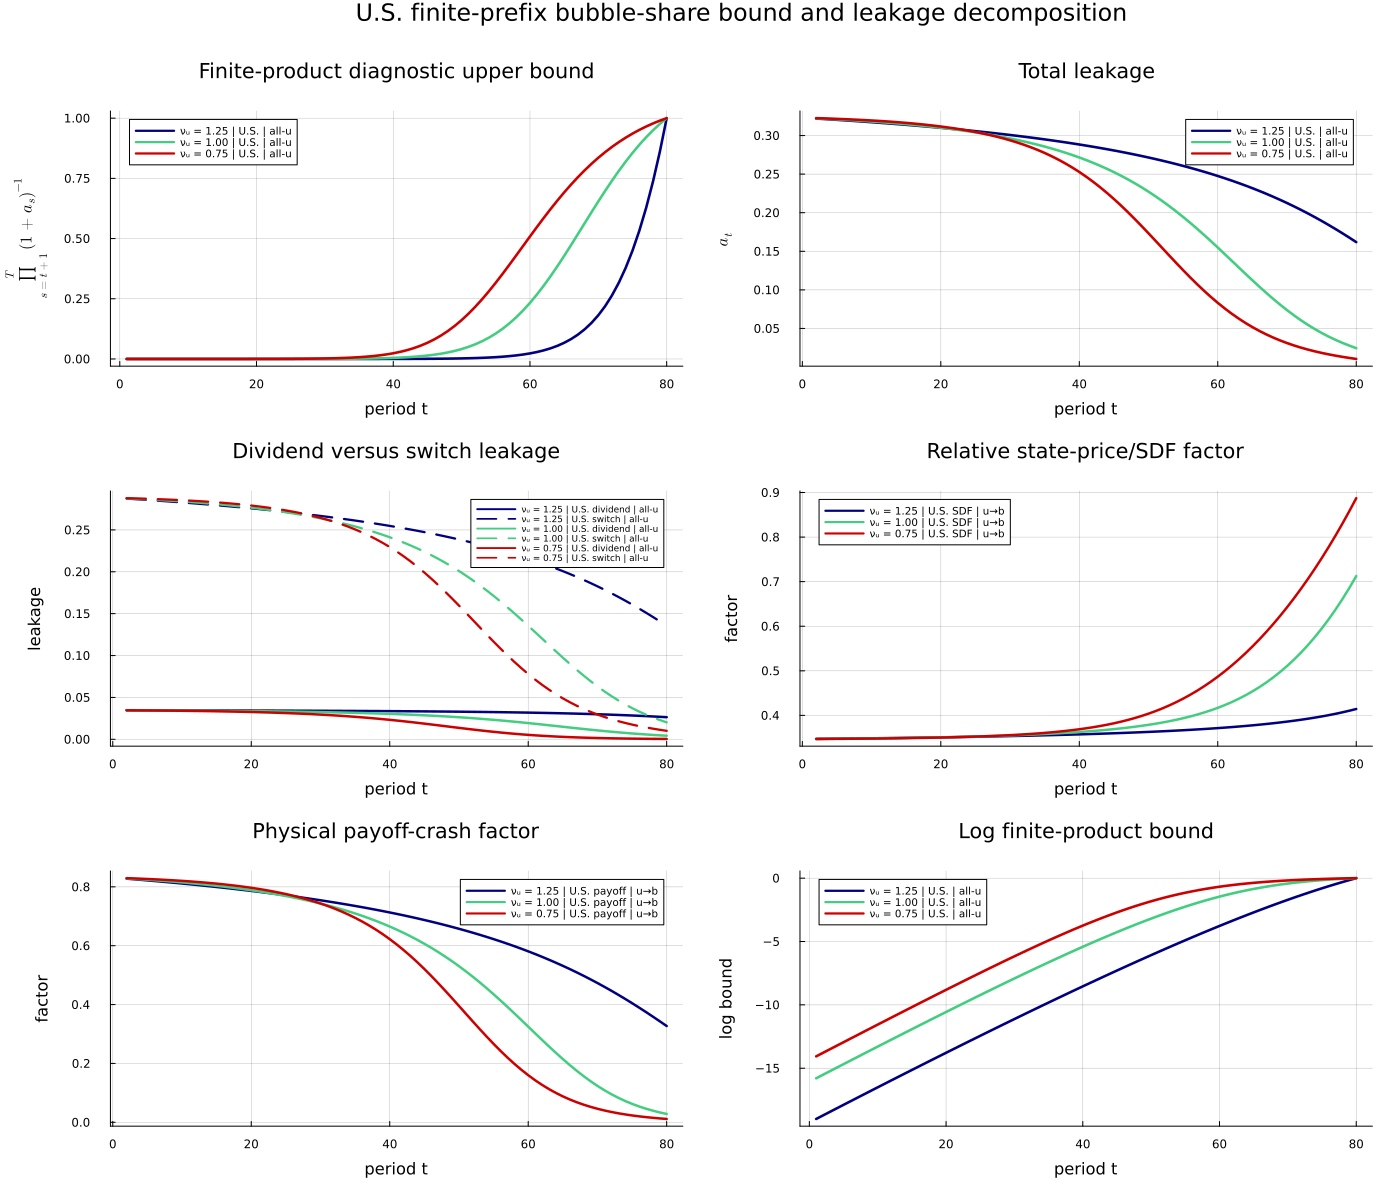

In [11]:
leak_specs=[
    (get=x->x.finite_bound,title="Finite-product diagnostic upper bound",
        ylabel=L"\prod_{s=t+1}^{T}(1+a_s)^{-1}",start=1),
    (get=x->x.total,title="Total leakage",ylabel=L"a_t",start=2),
    (get=x->x.log_bound,title="Log finite-product bound",ylabel="log bound",start=1),
]
leak_panels=Any[]
for spec in leak_specs
    p=plot(;title=spec.title,xlabel="period t",ylabel=spec.ylabel,
        legend=:best,legendfontsize=7,gridalpha=0.25)
    for x in nb05_leakage
        idx=spec.start:length(x.d.t)
        plot!(p,idx,spec.get(x)[idx];color=NB05_COLORS[x.d.case.id],lw=2.6,
            label="$(x.d.case.label) | U.S. | all-u")
    end
    push!(leak_panels,p)
end

p_leak_parts=plot(;title="Dividend versus switch leakage",xlabel="period t",ylabel="leakage",
    legend=:best,legendfontsize=6,gridalpha=0.25)
p_sdf=plot(;title="Relative state-price/SDF factor",xlabel="period t",ylabel="factor",
    legend=:best,legendfontsize=7,gridalpha=0.25)
p_physical=plot(;title="Physical payoff-crash factor",xlabel="period t",ylabel="factor",
    legend=:best,legendfontsize=7,gridalpha=0.25)
for x in nb05_leakage
    idx=2:length(x.d.t); c=NB05_COLORS[x.d.case.id]; lab=x.d.case.label
    plot!(p_leak_parts,idx,x.dividend[idx];color=c,lw=2.5,ls=:solid,
        label="$lab | U.S. dividend | all-u")
    plot!(p_leak_parts,idx,x.switch[idx];color=c,lw=2.3,ls=:dash,
        label="$lab | U.S. switch | all-u")
    plot!(p_sdf,idx,x.sdf[idx];color=c,lw=2.5,label="$lab | U.S. SDF | u→b")
    plot!(p_physical,idx,x.physical[idx];color=c,lw=2.5,
        label="$lab | U.S. payoff | u→b")
end
fig_leakage=plot(leak_panels[1],leak_panels[2],p_leak_parts,p_sdf,p_physical,
    leak_panels[3];layout=(3,2),size=(1400,1200),margin=5Plots.mm,
    plot_title="U.S. finite-prefix bubble-share bound and leakage decomposition")
savefig(fig_leakage,joinpath(NB05_OUTDIR,
    "us_bubble_share_bound_leakage_nu_u_sweep.png"))
fig_leakage


## 5. Verification and output manifest

The checks below enforce the reference note's definition of done: every requested case is explicitly accounted for; successful cases have a residual-safe no-buffer prefix no longer than 80; the two \(\zeta_t\) identities and the NFA adding-up identity hold numerically; realized switch paths use the stated \(\tau\); and finite-prefix objects remain explicitly distinguished from infinite-tail claims.


In [12]:
@assert length(nb05_horizon_rows)==length(NB05_CASES)
@assert all(r->0<=r.min_80_safe_horizon<=NB05_TARGET_T,nb05_horizon_rows)
@assert all(d->nb05_residual_safe(d.result),nb05_diag)
@assert all(d->d.identity_error_AB<=NB05_RESID_TOL &&
    d.identity_error_ratio<=NB05_RESID_TOL,nb05_diag)
@assert all(a->a.residual_max<=1e-8,nb05_nfa)
@assert all(d->isempty(d.realized) || d.realized[NB05_SWITCH_TAU].regime==:b,
    nb05_path_data)
@assert length(NB05_STATE_SPECS)*2*2==20

generated_files=[
    "residual_safe_horizon_summary.csv",
    "residual_safe_horizon_attempts.csv",
    "all_u_and_realized_switch_state_paths.csv",
    "all_u_state_paths_nu_u_sweep.png",
    "realized_switch_to_b_state_paths_nu_u_sweep.png",
    "stock_funding_and_ratio_paths.csv",
    "stock_funding_identity_summary.csv",
    "funding_identity_nu_u_sweep.png",
    "relative_scale_capitalization_nu_u_sweep.png",
    "finite_prefix_hkt_diagnostics.csv",
    "finite_prefix_hkt_diagnostics_nu_u_sweep.png",
    "us_nfa_va_ca_decomposition.csv",
    "us_nfa_identity_summary.csv",
    "us_nfa_va_ca_decomposition_nu_u_sweep.png",
    "us_nfa_positions_prices_nu_u_sweep.png",
    "us_bubble_share_bound_leakage.csv",
    "us_bubble_share_bound_summary.csv",
    "us_bubble_share_bound_leakage_nu_u_sweep.png",
]
@assert all(f->isfile(joinpath(NB05_OUTDIR,f)),generated_files)

manifest_rows=[
    (item="reference_structure",value="Reference_notes/On_Calibration_variablet_set.md"),
    (item="model_file",value=NB05_MODEL_FILE),
    (item="nu_u_grid",value="{1.25, 1.00, 0.75}"),
    (item="fixed_exponents",value="xi_u=2.25; nu_b=xi_W=0"),
    (item="target_horizon",value=string(NB05_TARGET_T)),
    (item="buffer",value="0"),
    (item="residual_tolerance",value=string(NB05_RESID_TOL)),
    (item="switch_tau",value=string(NB05_SWITCH_TAU)),
    (item="interpretation",value="finite-prefix diagnostics; no infinite-tail certification"),
    (item="generated_files",value=join(generated_files,";")),
]
nb05_write_csv(joinpath(NB05_OUTDIR,"run_manifest.csv"),manifest_rows,["item","value"])

println("NO_NOTEBOOK_ERRORS")
println("  Available calibrations: ",length(nb05_diag)," / ",length(NB05_CASES))
println("  Safe plotted horizons: ",
    join(["$(r.case_id):$(r.min_80_safe_horizon)" for r in nb05_horizon_rows],", "))
println("  Realized switch date: τ = ",NB05_SWITCH_TAU)
println("  Maximum ζ identity error: ",
    maximum(max(d.identity_error_AB,d.identity_error_ratio) for d in nb05_diag))
println("  Maximum NFA adding-up residual: ",
    maximum(a.residual_max for a in nb05_nfa))
println("  Output directory: ",NB05_OUTDIR)


NO_NOTEBOOK_ERRORS


  Available calibrations: 3 / 3
  Safe plotted horizons: nu_u_1_25:80, nu_u_1_00:80, nu_u_0_75:80
  Realized switch date: τ = 16
  Maximum ζ identity error: 

1.830785312240124e-8
  Maximum NFA adding-up residual: 1.0658141036401503e-14
  Output directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/05_nu_u_funding_regime_sweeps
